Epoch 1/5 complete
Epoch 2/5 complete
Epoch 3/5 complete
Epoch 4/5 complete
Epoch 5/5 complete
Training complete!
Performance = 0.1


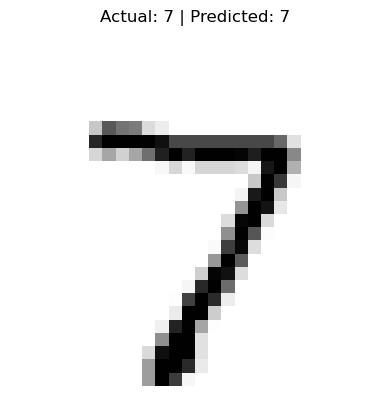

'#Too see different predictions \nfig = plt.figure(figsize=(8, 10))\n\nshown = {}\n\nfor record in test_data_list:\n\n    all_values = record.strip().split(\',\')\n    label = int(all_values[0])\n\n    # only show one per digit\n    if label in shown:\n        continue\n\n    image_array = np.array(all_values[1:], dtype=float).reshape((28, 28))\n\n    plt.subplot(4, 3, label + 1)\n    plt.imshow(image_array, cmap=\'Greys\')\n    plt.title(f"Digit: {label}")\n    plt.axis(\'off\')\n\n    shown[label] = True\n\n    if len(shown) == 10:\n        break\n\nplt.tight_layout()\nplt.show()'

In [16]:

import numpy as np
import scipy.special
import matplotlib.pyplot as plt

%matplotlib inline 
# Making sure that the plots open in this notebook

class neuralNetwork:

    def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate):
        
        self.inodes = inputnodes
        self.hnodes = hiddennodes
        self.onodes = outputnodes

        # weight matrices
        self.wih = np.random.normal(0.0, pow(self.hnodes, -0.5),
                                   (self.hnodes, self.inodes))
        self.who = np.random.normal(0.0, pow(self.onodes, -0.5),
                                   (self.onodes, self.hnodes))

        self.lr = learningrate

        self.activation_function = lambda x: scipy.special.expit(x)


    def train(self, inputs_list, targets_list):
        inputs = np.array(inputs_list, ndmin=2).T
        targets = np.array(targets_list, ndmin=2).T

        # forward pass
        hidden_inputs = np.dot(self.wih, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)

        final_inputs = np.dot(self.who, hidden_outputs)
        final_outputs = self.activation_function(final_inputs)

        # errors
        output_errors = targets - final_outputs
        hidden_errors = np.dot(self.who.T, output_errors)

        # update weights
        self.who += self.lr * np.dot(
            (output_errors * final_outputs * (1.0 - final_outputs)),
            hidden_outputs.T
        )

        self.wih += self.lr * np.dot(
            (hidden_errors * hidden_outputs * (1.0 - hidden_outputs)),
            inputs.T
        )


    def query(self, inputs_list):
        inputs = np.array(inputs_list, ndmin=2).T

        hidden_inputs = np.dot(self.wih, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)

        final_inputs = np.dot(self.who, hidden_outputs)
        final_outputs = self.activation_function(final_inputs)

        return final_outputs


input_nodes = 784
hidden_nodes = 200
output_nodes = 10
learning_rate = 0.1

n = neuralNetwork(input_nodes, hidden_nodes, output_nodes, learning_rate)


train_path = "C://Users//HP//Desktop//mnist_train_100.csv"
test_path  = "C://Users//HP//Desktop//mnist_test_10.csv"


with open(train_path, 'r') as f:
    training_data_list = f.readlines()


epochs = 5

for e in range(epochs):
    for record in training_data_list:
        all_values = record.split(',')

        if len(all_values) < 785:
            continue

        # inputs
        inputs = (np.array(all_values[1:], dtype=float) / 255.0 * 0.99) + 0.01

        # targets
        targets = np.zeros(output_nodes) + 0.01
        targets[int(all_values[0])] = 0.99

        n.train(inputs, targets)

    print(f"Epoch {e+1}/{epochs} complete")

print("Training complete!")


with open(test_path, 'r') as f:
    test_data_list = f.readlines()


scorecard = []

for record in test_data_list:
    all_values = record.split(',')

    if len(all_values) < 785:
        continue

    correct_label = int(all_values[1])

    inputs = (np.array(all_values[1:], dtype=float) / 255.0 * 0.99) + 0.01

    outputs = n.query(inputs)
    label = np.argmax(outputs)

    if label == correct_label:
        scorecard.append(1)
    else:
        scorecard.append(0)


scorecard_array = np.asarray(scorecard)

print("Performance =", scorecard_array.sum() / scorecard_array.size)

#IMAGE + PREDICTION

# choose which record to view
index = 0  # change this number to see different images

record = test_data_list[index]
all_values = record.strip().split(',')

# actual label
correct_label = int(all_values[0])

# convert pixels to image
image_array = np.array(all_values[1:], dtype=float).reshape((28, 28))

# prepare input for network
inputs = (np.array(all_values[1:], dtype=float) / 255.0 * 0.99) + 0.01

# get prediction
outputs = n.query(inputs)
predicted_label = np.argmax(outputs)

plt.imshow(image_array, cmap='Greys', interpolation='None')
plt.title(f"Actual: {correct_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()


'''#Too see different predictions 
fig = plt.figure(figsize=(8, 10))

shown = {}

for record in test_data_list:

    all_values = record.strip().split(',')
    label = int(all_values[0])

    # only show one per digit
    if label in shown:
        continue

    image_array = np.array(all_values[1:], dtype=float).reshape((28, 28))

    plt.subplot(4, 3, label + 1)
    plt.imshow(image_array, cmap='Greys')
    plt.title(f"Digit: {label}")
    plt.axis('off')

    shown[label] = True

    if len(shown) == 10:
        break

plt.tight_layout()
plt.show()'''